In [2]:
import numpy as np
def neurona_mcculloch_pitts(entradas, pesos, umbral):
    # Calcular la suma ponderada de las entradas
    suma_ponderada = np.dot(entradas, pesos)
    # Aplicar la funci´on de activaci´on (escal´on de Heaviside)
    salida = 1.0 if suma_ponderada >= umbral else 0.0
    return salida

# Valores de entrada
entradas = np.array([0.5, 0.3, 0.8])
pesos = np.array([0.2, 0.4, 0.6])
umbral = 0.7

# Calcular la salida de la neurona
salida = neurona_mcculloch_pitts(entradas, pesos, umbral)
print("Salida:", salida)

Salida: 1.0


In [3]:
import pandas as pd
columnas = ['x1', 'x2', 'AND']
puerta_and = [[0, 0, 0], [0, 1, 0], [1, 0, 0], [1, 1, 1]]
tabla = pd.DataFrame(puerta_and, columns=columnas)
tabla.head()

,x1,x2,AND
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


In [4]:
# AND

casos = [
([0, 0], 0),
([0, 1], 0),
([1, 0], 0),
([1, 1], 1),
]
pesos = np.array([1, 1])
umbral = 2

for i,_ in enumerate(casos):
    salida = neurona_mcculloch_pitts(casos[i][0], pesos, umbral)
    print(salida)

0.0
0.0
0.0
1.0


In [5]:
# OR

casos = [
([0, 0], 0),
([0, 1], 1),
([1, 0], 1),
([1, 1], 1),
]
pesos = np.array([1, 1])
umbral = 1

for i,_ in enumerate(casos):
    salida = neurona_mcculloch_pitts(casos[i][0], pesos, umbral)
    print(salida)

0.0
1.0
1.0
1.0


In [ ]:
# AND

from sklearn.linear_model import Perceptron
X = tabla.values[:, 0:2]
y = tabla.values[:, 2]
nn = Perceptron(eta0=0.01, max_iter=10, random_state=1)
nn.fit(X, y)
print(nn.coef_) # pesos
print(nn.intercept_) # sesgo

[[0.02 0.02]]
[-0.03]


c:\Users\rock-\Downloads\Facultad\Ciencia_de_Datos\.sklearn-env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [8]:
from sklearn.metrics import accuracy_score
y_pred = nn.predict(X)
print("Precisión:", accuracy_score(y, y_pred))
print("Salidas predichas:", y_pred)

Precisión: 1.0
Salidas predichas: [0 0 0 1]


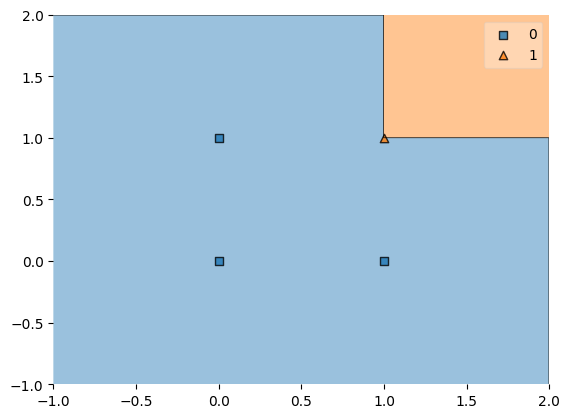

In [10]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
plot_decision_regions(X, y, clf=nn)
plt.show()

In [11]:
print("w1 =", nn.coef_[0][0])
print("w2 =", nn.coef_[0][1])
print("b =", nn.intercept_[0])
print("Recta: x1 + x2 =", round(-nn.intercept_[0]/nn.coef_[0][0], 2))

w1 = 0.019999999999999997
w2 = 0.02
b = -0.03
Recta: x1 + x2 = 1.5


In [12]:
# OR

columnas = ['x1', 'x2', 'OR']
puerta_and = [[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 1]]
tabla = pd.DataFrame(puerta_and, columns=columnas)
tabla.head()

,x1,x2,OR
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,1


[[0.02 0.02]]
[-0.01]
Precisión: 1.0
Salidas predichas: [0 1 1 1]


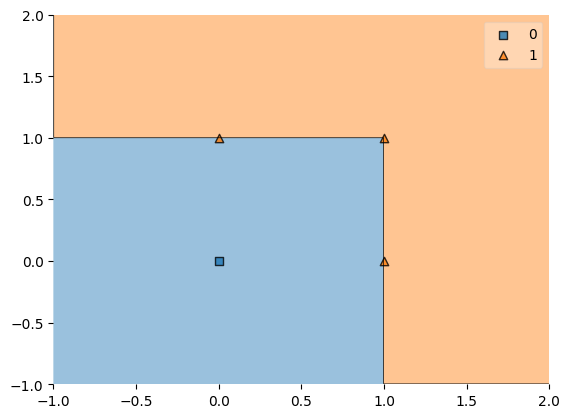

w1 = 0.02
w2 = 0.02
b = -0.01
Recta: x1 + x2 = 0.5


In [18]:
X = tabla.values[:, 0:2]
y = tabla.values[:, 2]
nn = Perceptron(eta0=0.01, max_iter=10, random_state=1)
nn.fit(X, y)
print(nn.coef_) # pesos
print(nn.intercept_) # sesgo

y_pred = nn.predict(X)
print("Precisión:", accuracy_score(y, y_pred))
print("Salidas predichas:", y_pred)

plot_decision_regions(X, y, clf=nn)
plt.show()

print("w1 =", nn.coef_[0][0])
print("w2 =", nn.coef_[0][1])
print("b =", nn.intercept_[0])
print("Recta: x1 + x2 =", round(-nn.intercept_[0]/nn.coef_[0][0], 2))

In [21]:
# XOR

columnas = ['x1', 'x2', 'OR']
puerta_and = [[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 0]]
tabla = pd.DataFrame(puerta_and, columns=columnas)
tabla.head()

,x1,x2,OR
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


[[ 0.   -0.01]]
[0.]
Precisión: 0.5
Salidas predichas: [0 0 0 0]


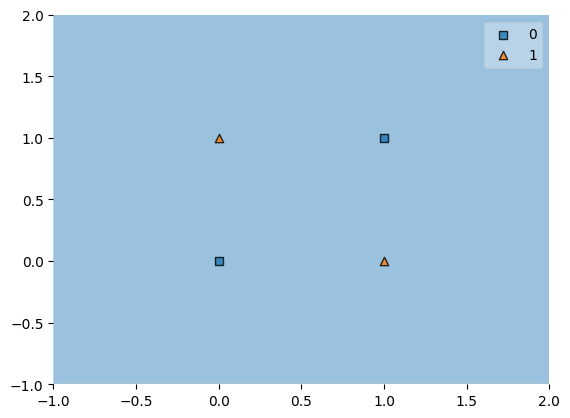

w1 = 0.0
w2 = -0.01
b = 0.0
Recta: x1 + x2 = nan


C:\Users\rock-\AppData\Local\Temp\ipykernel_25508\1898079588.py:18: RuntimeWarning: invalid value encountered in scalar divide
  print("Recta: x1 + x2 =", round(-nn.intercept_[0]/nn.coef_[0][0], 2))


In [24]:
X = tabla.values[:, 0:2]
y = tabla.values[:, 2]
nn = Perceptron(eta0=0.01, max_iter=10, random_state=1)
nn.fit(X, y)
print(nn.coef_) # pesos
print(nn.intercept_) # sesgo

y_pred = nn.predict(X)
print("Precisión:", accuracy_score(y, y_pred))
print("Salidas predichas:", y_pred)

plot_decision_regions(X, y, clf=nn)
plt.show()

print("w1 =", nn.coef_[0][0])
print("w2 =", nn.coef_[0][1])
print("b =", nn.intercept_[0])
print("Recta: x1 + x2 =", round(-nn.intercept_[0]/nn.coef_[0][0], 2))

1.0


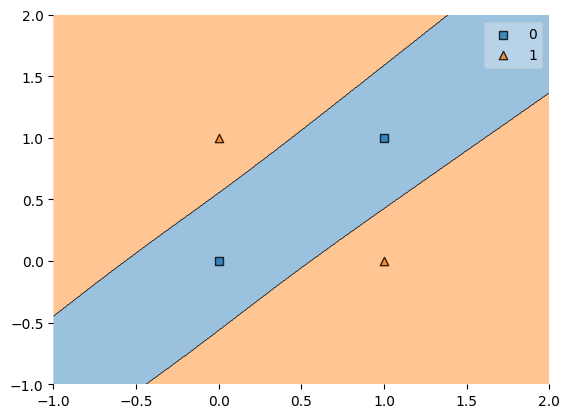

In [27]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(3,), activation='logistic', solver='lbfgs', random_state=1, max_iter=1000)

mlp.fit(X, y)
y_pred = mlp.predict(X)
print(accuracy_score(y, y_pred))
plot_decision_regions(X.astype(np.float32), y.astype(np.int32), clf=mlp)
plt.show()

#### Tarea 9

#### En esta tarea trabajaremos con el conjunto de datos de cáncer de mama que hemos estudiado anteriormente.

##### 1. Carga el conjunto de datos de cáncer de mama desde `Scikit-learn` y divide el conjunto en entrenamiento (80%) y prueba (20%).

In [50]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

seed = 123

dataset = load_breast_cancer()
X = dataset["data"]
y = dataset["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)

mlp = MLPClassifier(hidden_layer_sizes=(10,10), activation='tanh', random_state=seed, max_iter=1000)

mlp.fit(X_train, y_train)
print(accuracy_score(y_test, mlp.predict(X_test)))

0.631578947368421


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ValueError: Expected 2D array, got 1D array instead:
array=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 1. 1. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1.
 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0.
 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0.
 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1.
 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 0.
 0. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1.
 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0.
 1. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0.
 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1